# Student Performance Prediction
## A comparative study of ML models on the OULAD Dataset
### What this project does (A Big Picture)
- We are using OULAD dataset which provides us with ~30,000 university students - their demographics (age, gender, region, etc) and their scores on assessments.
- Our goal: can we predict whether a student will pass or fail?
- We are going to train 3 machine learning models and compare them:
  - Logistic Regression
  - XGBoost
  - Neural Network (MLP)

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from xgboost import XGBClassifier

## Loading Data

In [2]:
info = pd.read_csv("studentInfo.csv", na_values="?")
assess = pd.read_csv("studentAssessment.csv", na_values="?")

In [3]:
info.head()

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass


In [4]:
assess.head()

,id_assessment,id_student,date_submitted,is_banked,score
0,1752,11391,18,0,78.0
1,1752,28400,22,0,70.0
2,1752,31604,17,0,72.0
3,1752,32885,26,0,69.0
4,1752,38053,19,0,79.0


In [5]:
print(info.shape)
print(assess.shape)

(32593, 12)
(173912, 5)


## Cleaning Data

In [6]:
# convert values in scores column into numbers, if the value is other than number (e.g. N/A or ?), put NaN instead
assess['score'] = pd.to_numeric(assess['score'], errors='coerce')

# delete any row where the score column is NaN
assess = assess.dropna(subset=['score'])

In [7]:
print(assess.shape)

(173739, 5)


## Create Target Variable

- The `final_result` column in the info dataset has 4 different values viz Pass, Distinction, Fail, and Withdrawn
- To simplify the classification, we want to convert that one column into 4 different columns so, we can use 0 and 1 to label whether Pass is yes or no or Distinction is yes or no.
- This is what the model will be trained on to predict the outcome

In [8]:
info['passed'] = info['final_result'].map({
    'Pass': 1,
    'Distinction': 1,
    'Fail': 0,
    'Withdrawn': 0,
})
info.shape

(32593, 13)

In [9]:
# remove rows from the dataset where the value of 'passed' column is empty
info = info.dropna(subset=['passed'])
info.shape

(32593, 13)

In [10]:
# converting decimal values to integers in passed column using astype()
info['passed'] = info['passed'].astype(int)

In [11]:
# count the number of students passed/failed
pass_counts = info['passed'].value_counts()
print(f"   Pass (1): {pass_counts[1]} students  ({pass_counts[1]/len(info)*100:.1f}%)")
print(f"   Fail (0): {pass_counts[0]} students  ({pass_counts[0]/len(info)*100:.1f}%)")

   Pass (1): 15385 students  (47.2%)
   Fail (0): 17208 students  (52.8%)


## Summarizing Scores for Each Student

- The assessment file has multiple rows per student (one per quiz)
- We need one row per student to combine with their profile
- So, all of the quiz rows will be collapsed into number of quizzes, score average, and standard deviation to understand their consistency

In [12]:
# Using groupby() to combine all the rows that belong to the same student
# and agg() to calculate average, standard deviation, and total number of quizzes
student_features = assess.groupby('id_student').agg(
    avg_score = ('score', 'mean'),
    score_std = ('score', 'std'),
    num_assessments = ('score', 'count')
).reset_index()

student_features

,id_student,avg_score,score_std,num_assessments
0,6516,61.800000,10.329569,5
1,8462,87.000000,4.472136,7
2,11391,82.000000,3.082207,5
3,23629,82.500000,20.273135,4
4,23698,74.444444,13.258121,9
...,...,...,...,...
23346,2698251,58.142857,14.415600,7
23347,2698257,67.800000,7.362065,5
23348,2698535,39.250000,19.564910,8
23349,2698577,64.400000,19.969977,5


## Merging Datasets
- Merging the info and student_features tables together

In [13]:
# Merging the two tables using the student ID via merge()
# `how='inner'` means similar inner join in SQL i.e.
# keep the rows that exist in both tables
df = pd.merge(info, student_features, on='id_student', how='inner')
df.head()

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,passed,avg_score,score_std,num_assessments
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,1,82.0,3.082207,5
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass,1,66.4,4.335897,5
2,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass,1,76.0,6.892024,5
3,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass,1,54.4,20.513410,5
4,AAA,2013J,38053,M,Wales,A Level or Equivalent,80-90%,35-55,0,60,N,Pass,1,68.0,10.977249,5


In [14]:
df.shape


(26727, 16)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26727 entries, 0 to 26726
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   code_module           26727 non-null  object 
 1   code_presentation     26727 non-null  object 
 2   id_student            26727 non-null  int64  
 3   gender                26727 non-null  object 
 4   region                26727 non-null  object 
 5   highest_education     26727 non-null  object 
 6   imd_band              25714 non-null  object 
 7   age_band              26727 non-null  object 
 8   num_of_prev_attempts  26727 non-null  int64  
 9   studied_credits       26727 non-null  int64  
 10  disability            26727 non-null  object 
 11  final_result          26727 non-null  object 
 12  passed                26727 non-null  int64  
 13  avg_score             26727 non-null  float64
 14  score_std             24595 non-null  float64
 15  num_assessments    

In [16]:
df['num_assessments'].min()

1

In [17]:
df['num_assessments'].max()

28

In [18]:
df['studied_credits'].min()

30

In [19]:
df['studied_credits'].max()

630

## Visualization 01 - Class Distribution

### Chart 01: Pass vs. Fail Count
- How many students passed vs. failed?
- A bar chart:
  - red bar = failed
  - green bar = passed
 
### Chart 02: Average Score
- Do students who pass score higher on average?
- Two overlapping histograms - one for students who passed and one for students who failed
- If the two histograms overlap a lot, scores alone do not tell us much
- If they are far apart, scores are a strong predictor

### Chart 03: Credits vs Pass Rate
- Does taking more credits affect passing?
- Grouping students by how many credits they studied, then calculating pass rate for each group.

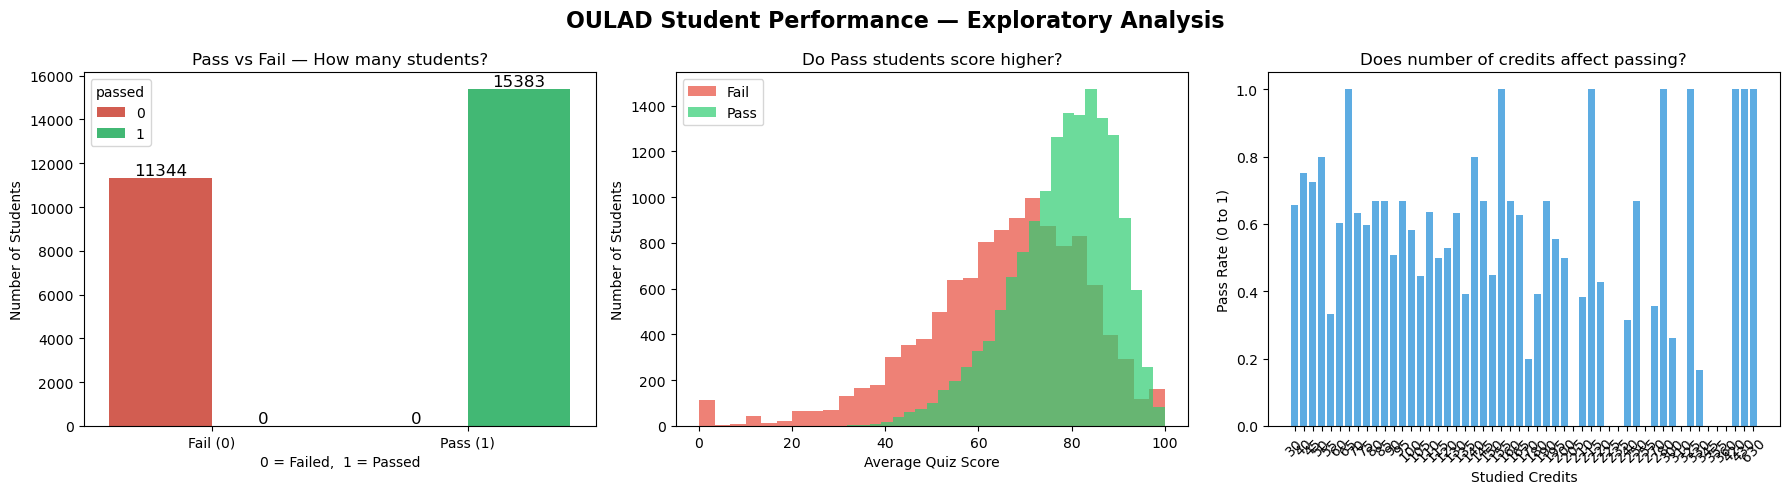

In [20]:
# Make a canvas with 3 charts side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('OULAD Student Performance — Exploratory Analysis', fontsize=16, fontweight='bold')

# -------------------------------
# Chart 1: Pass vs Fail Count
# -------------------------------
sns.countplot(x='passed', data=df, hue='passed', palette=['#e74c3c', '#2ecc71'], ax=axes[0])
axes[0].set_title('Pass vs Fail — How many students?')
axes[0].set_xlabel('0 = Failed,  1 = Passed')
axes[0].set_ylabel('Number of Students')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Fail (0)', 'Pass (1)'])

for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=12)

# -------------------------------
# Chart 2: Average Score
# -------------------------------
fail_scores = df[df['passed'] == 0]['avg_score']
pass_scores = df[df['passed'] == 1]['avg_score']

axes[1].hist(fail_scores, bins=30, alpha=0.7, color='#e74c3c', label='Fail')
axes[1].hist(pass_scores, bins=30, alpha=0.7, color='#2ecc71', label='Pass')
axes[1].set_title('Do Pass students score higher?')
axes[1].set_xlabel('Average Quiz Score')
axes[1].set_ylabel('Number of Students')
axes[1].legend()

# -------------------------------
# Chart 3: Credits vs Pass Rate
# -------------------------------
credit_pass = df.groupby('studied_credits')['passed'].mean().reset_index()
axes[2].bar(credit_pass['studied_credits'].astype(str), credit_pass['passed'],
            color='#3498db', alpha=0.8)
axes[2].set_title('Does number of credits affect passing?')
axes[2].set_xlabel('Studied Credits')
axes[2].set_ylabel('Pass Rate (0 to 1)')
axes[2].tick_params(axis='x', rotation=45)

# Show charts
plt.tight_layout()
plt.show()

## Encoding Categorical Variables
- Converting every text column into 0s and 1s using one-hot encoding

In [21]:
exclude_cols = ["id_student", "passed", "final_result", "avg_score"]

# finding all the columns that contain text excluding exclude_cols
categorical_cols = [col for col in df.select_dtypes(include=["object"]).columns if col not in exclude_cols]

categorical_cols

['code_module',
 'code_presentation',
 'gender',
 'region',
 'highest_education',
 'imd_band',
 'age_band',
 'disability']

In [22]:
# get_dummies() actually performs the one-hot encoding
# drop_first=True removes one duplicate category from each column
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [23]:
df_encoded

,id_student,num_of_prev_attempts,studied_credits,final_result,passed,avg_score,score_std,num_assessments,code_module_BBB,code_module_CCC,...,imd_band_30-40%,imd_band_40-50%,imd_band_50-60%,imd_band_60-70%,imd_band_70-80%,imd_band_80-90%,imd_band_90-100%,age_band_35-55,age_band_55<=,disability_Y
0,11391,0,240,Pass,1,82.000000,3.082207,5,False,False,...,False,False,False,False,False,False,True,False,True,False
1,28400,0,60,Pass,1,66.400000,4.335897,5,False,False,...,False,False,False,False,False,False,False,True,False,False
2,31604,0,60,Pass,1,76.000000,6.892024,5,False,False,...,False,False,True,False,False,False,False,True,False,False
3,32885,0,60,Pass,1,54.400000,20.513410,5,False,False,...,False,False,True,False,False,False,False,False,False,False
4,38053,0,60,Pass,1,68.000000,10.977249,5,False,False,...,False,False,False,False,False,True,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26722,2620947,0,30,Distinction,1,88.888889,10.833333,9,False,False,...,False,False,False,False,False,True,False,False,False,True
26723,2645731,0,30,Distinction,1,88.111111,11.580635,9,False,False,...,False,True,False,False,False,False,False,True,False,False
26724,2648187,0,30,Pass,1,76.666667,15.206906,9,False,False,...,False,False,False,False,False,False,False,False,False,True
26725,2679821,0,30,Withdrawn,0,91.500000,12.020815,2,False,False,...,False,False,False,False,False,False,True,True,False,False


## Defining Features (X) and Target (Y)
- We removed:
  - `id_student`: just an ID number, not useful for prediction
  - `passed`: this is the target variable, not a feature
  - `final_result`: this is the raw version of the target variable
  - `avg_score` - this is removed because it is also directly linked to passing, in order to make the prediction more challenging and realistic

In [24]:
cols_to_drop = ['id_student', 'passed', 'avg_score'] + \
               [col for col in df_encoded.columns if 'final_result' in col]

In [25]:
X = df_encoded.drop(columns=cols_to_drop)

In [26]:
y = df_encoded['passed']

## Train/Test Split
- Training set 80%
- Testing set 20%

In [27]:
# random_state=42 makes sure that the split is always the same every time we run the code
# stratify=y makes sure that both train/test sets have the same ratio of pass/fail students
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [28]:
X_train.shape[0]

21381

In [29]:
X_test.shape[0]

5346

## Feature Scaling/Data Normalization

- Some features have very different ranges:
  - `num_assessments` ranges from 1 to 28
  - `studied_credits` ranges from 30 to 630
 
- Logistic Regression and Neural Networks are sensitive to this.
- They give more weight to larger numbers even if they are not more important.

- We are using StandardScaler to normalize every feature
  - mean = 0
  - standard deviation = 1


In [30]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [31]:
# Fill any remaining missing values with 0
X_train_scaled = np.nan_to_num(X_train_scaled)
X_test_scaled = np.nan_to_num(X_test_scaled)

## Helper Function to Evaluate a Model
- This function takes a trained model and test data, makes predictions, prints all the metrics, and returns the scores.

In [32]:
def evaluate_model(name, model, X_test_data, y_test_data):
    """
    Evaluates a trained model and prints its performance metrics.
    
    Parameters:
        name        - Name of the model (for display)
        model       - The trained sklearn model object
        X_test_data - Test features
        y_test_data - True test labels
    
    Returns:
        dict with accuracy, precision, recall, f1
    """
    # make predictions on the test set
    # .predict() outputs 0 or 1 for each statement
    y_pred = model.predict(X_test_data)

    # calculate metrics
    acc = accuracy_score(y_test_data, y_pred)
    prec = precision_score(y_test_data, y_pred, zero_division=0)
    rec = recall_score(y_test_data, y_pred, zero_division=0)
    f1 = f1_score(y_test_data, y_pred, zero_division=0)

    print(name)
    print("")
    print("Accuracy:   " + str(round(acc, 4)))
    print("Precision:  " + str(round(prec, 4)))
    print("Recall:     " + str(round(rec, 4)))
    print("F1 Score:   " + str(round(f1, 4)))
    print("")
    print(classification_report(y_test_data, y_pred, target_names=['Fail', 'Pass']))

    return {'name': name, 'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1,
            'y_pred': y_pred}
    

## Model 01: Logistic Regression
- Logistic Regression draws a straight line that separates Pass students from Fail students.
- It outputs a probability (0 to 1) of passing then:
  - probablity >= 0.5 predicts Pass (1)
  - probability < 0.5 predicts Fail (0)

In [33]:
lr_model = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
lr_model.fit(X_train_scaled, y_train)

lr_results = evaluate_model("MODEL 01: Logistic Regression", lr_model, X_test_scaled, y_test)

MODEL 01: Logistic Regression

Accuracy:   0.809
Precision:  0.8041
Recall:     0.8833
F1 Score:   0.8419

              precision    recall  f1-score   support

        Fail       0.82      0.71      0.76      2269
        Pass       0.80      0.88      0.84      3077

    accuracy                           0.81      5346
   macro avg       0.81      0.80      0.80      5346
weighted avg       0.81      0.81      0.81      5346



## Model 02: XGBoost
- more info

In [34]:
# COLUMN NAMES 
X.columns = X.columns.str.replace(r'[\[\]<]', '', regex=True)

# (recreate split AFTER fixing columns to keep consistency)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

#  HANDLE MISSING VALUES 
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

#  MODEL
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

# TRAIN 
xgb_model.fit(X_train, y_train)

#  EVALUATE 
xgb_results = evaluate_model(
    "MODEL 02: XGBoost",
    xgb_model,
    X_test,
    y_test
)

MODEL 02: XGBoost

Accuracy:   0.8649
Precision:  0.8422
Recall:     0.9418
F1 Score:   0.8892

              precision    recall  f1-score   support

        Fail       0.91      0.76      0.83      2269
        Pass       0.84      0.94      0.89      3077

    accuracy                           0.86      5346
   macro avg       0.87      0.85      0.86      5346
weighted avg       0.87      0.86      0.86      5346



## Model 03: Neural Network (MLP)
- more info

In [ ]:
## Model 03: Neural Network (MLP)

# -------- HANDLE MISSING VALUES (just in case) --------
X_train_scaled = np.nan_to_num(X_train_scaled)
X_test_scaled = np.nan_to_num(X_test_scaled)

# -------- MODEL --------
mlp_model = MLPClassifier(
    hidden_layer_sizes=(100, 50),
    activation='relu',
    solver='adam',
    max_iter=1000,
    random_state=42
)

# -------- TRAIN --------
mlp_model.fit(X_train_scaled, y_train)

# -------- EVALUATE --------
mlp_results = evaluate_model(
    "MODEL 03: Neural Network",
    mlp_model,
    X_test_scaled,
    y_test
)

MODEL 03: Neural Network (MLP)

Accuracy:   0.8227
Precision:  0.8282
Recall:     0.8729
F1 Score:   0.85

              precision    recall  f1-score   support

        Fail       0.81      0.75      0.78      2269
        Pass       0.83      0.87      0.85      3077

    accuracy                           0.82      5346
   macro avg       0.82      0.81      0.82      5346
weighted avg       0.82      0.82      0.82      5346



/Users/negarkamvij/anaconda3/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


## Visualization 02 - Model Comparison Bar Chart

                             name  accuracy  precision    recall        f1
0   MODEL 01: Logistic Regression  0.809016   0.804142  0.883328  0.841877
1               MODEL 02: XGBoost  0.864946   0.842197  0.941826  0.889230
2  MODEL 03: Neural Network (MLP)  0.822671   0.828245  0.872928  0.850000


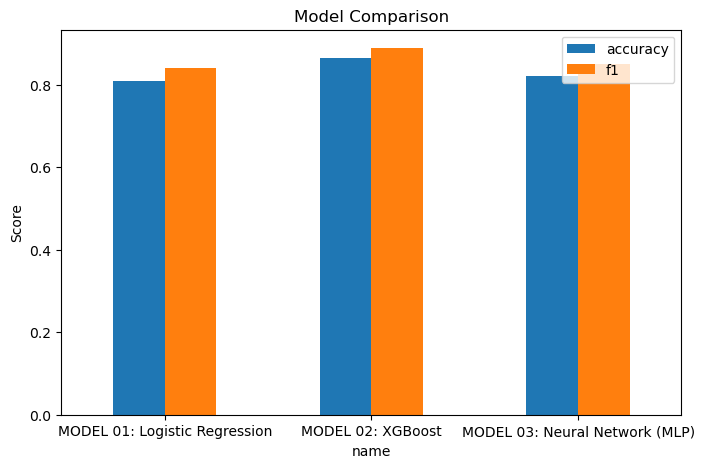

In [40]:
results = [lr_results, xgb_results, mlp_results]

summary = pd.DataFrame(results)[["name", "accuracy", "precision", "recall", "f1"]]

# print table
print(summary)

# create bar chart
summary.set_index("name")[["accuracy", "f1"]].plot(kind="bar", figsize=(8,5))

plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

## Visualization 03 - Confusion Matrices
- more info

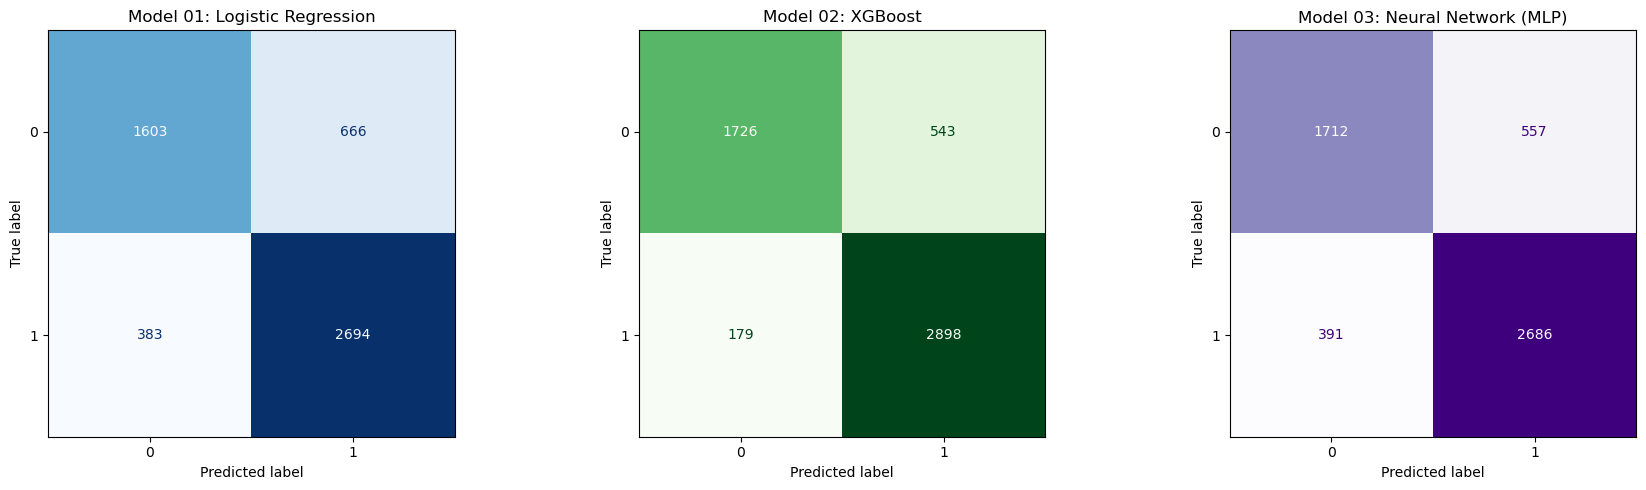

In [41]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# create 3 plots side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Model 01: Logistic Regression (USE SCALED)
ConfusionMatrixDisplay.from_estimator(
    lr_model,
    X_test_scaled,
    y_test,
    ax=axes[0],
    cmap='Blues',
    colorbar=False
)
axes[0].set_title("Model 01: Logistic Regression")

# Model 02: XGBoost (USE RAW DATA)
ConfusionMatrixDisplay.from_estimator(
    xgb_model,
    X_test,
    y_test,
    ax=axes[1],
    cmap='Greens',
    colorbar=False
)
axes[1].set_title("Model 02: XGBoost")

# Model 03: Neural Network (USE SCALED)
ConfusionMatrixDisplay.from_estimator(
    mlp_model,
    X_test_scaled,
    y_test,
    ax=axes[2],
    cmap='Purples',
    colorbar=False
)
axes[2].set_title("Model 03: Neural Network (MLP)")

plt.tight_layout()
plt.show()

## Visualization 04 - XGBoost Feature Importance
- more info

In [38]:
# code

## Final Summary Table
- more info

In [39]:
# code